In [1]:
from dotenv import load_dotenv
load_dotenv(".env", override=True)
%load_ext autoreload
%autoreload 2

# Deepagent for Research

We will use the `deepagents` package to create a research agent. When using the `deepagents` package, it's important to: 

1. Understand the native tools available
2. Supply task-specific tools
3. Supply task-specific instructions
4. Supply task-specific sub-agents

## Task-Specific Tools 

You can see an overview of the native tools in the [deepagents package README](https://github.com/langchain-ai/deepagents?tab=readme-ov-file#model) as well as the [quickstarts README](https://github.com/langchain-ai/deepagents-quickstarts). We'll extend this with two task-specific tools. 

### Search Tool 

There are different search tools that we can use. For example, we can use [Tavily](https://www.tavily.com/) to search for relevant URLs, then fetches the full webpage content.

### Think Tool 

We'll supply a [think tool](https://www.anthropic.com/engineering/claude-think-tool), which is a useful way to help audit agent decision making. 

In [2]:
from research_agent.tools import tavily_search, think_tool
tools = [tavily_search, think_tool]

## Task-Specific Instructions
 
Next, let's define task specific instructions using [a few prompting techniques for agents](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA):

### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Start with broader searches** - Use broad, comprehensive queries first
- **After each search, pause and assess** - Do I have enough to answer? What's still missing?
- **Execute narrower searches as you gather information** - Fill in the gaps.

### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Stop when you can answer confidently** - Don't keep searching for perfection.
- **Give it budgets** - Use 2-3 search tool calls for simple queries. Use up to 5 for complex queries.
- **Limit** - Always stop after 5 search tool calls if you cannot find the right source(s).

### 3. Show your thinking
After each search tool calling, use [`think_tool` to analyze the results](https://www.anthropic.com/engineering/claude-think-tool):
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

In [3]:
from datetime import datetime
from utils import show_prompt, format_messages
from research_agent.prompts import (
    RESEARCHER_INSTRUCTIONS,
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,
)

In [4]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the research tools provided to you to find resources that can help answer the research      │
│  question.                                                                                                      │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Research Tools>                                                                                     │
│  You have access to two specific research tools:                                                                │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Research Tools>                                                                                    │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

## Task-Specific Sub-Agents

You can specify [custom subagents](https://github.com/langchain-ai/deepagents?tab=readme-ov-file#subagents) as a means of context isolation. 

Here's well define a sub-agent that can search the web for information. 

In [5]:
# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}

## Putting it all together

### Instructions

Now, we can look at all of our instructions together. 

In [6]:
# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Combine orchestrator instructions (RESEARCHER_INSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    +  SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Research Workflow                                                                                            │
│                                                                                                                 │
│  Follow this workflow for all research requests:                                                                │
│                                                                                                                 │
│  1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks                 │
│  2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`       │
│  3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for       │
│  research, never conduct research yourself                                                                      │
│  4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number    │
│  across all findings)                                                                                           │
│  5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines   │
│  below)                                                                                                         │
│  6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and  │
│  structure                                                                                                      │
│                                                                                                                 │
│  ## Research Planning Guidelines                                                                                │
│  - Batch similar research tasks into a single TODO to minimize overhead                                         │
│  - For simple fact-finding questions, use 1 sub-agent                                                           │
│  - For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents                            │
│  - Each sub-agent should research one specific aspect and return findings                                       │
│                                                                                                                 │
│  ## Report Writing Guidelines                                                                                   │
│                                                                                                                 │
│  When writing the final report to `/final_report.md`, follow these structure patterns:                          │
│                                                                                                                 │
│  **For comparisons:**                                                                                           │
│  1. Introduction                                                                                                │
│  2. Overview of topic A                                                                                         │
│  3. Overview of topic B                                                                                         │
│  4. Detailed comparison                                                                                         │
│  5. Conclusion                                                                                                  │
│                                                                                                                 │
│  **For lists/rankings:**                              

### Create the agent

Now, we create our deepagent with these components. 

In [7]:
from IPython.display import Image, display
from deepagents import create_deep_agent
from langchain.chat_models import init_chat_model
from langchain_google_genai import ChatGoogleGenerativeAI

# Model Gemini 3 
model = ChatGoogleGenerativeAI(model="gemini-3-pro-preview")

# Model Claude 4.5
#model = init_chat_model(model="anthropic:claude-sonnet-4-5-20250929", temperature=0.0)

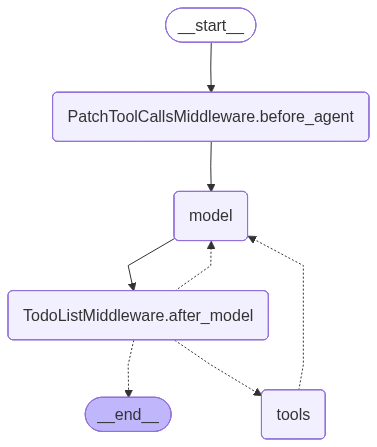

In [8]:
# Create the agent
agent = create_deep_agent(
      model=model,
      tools=tools, 
      system_prompt=INSTRUCTIONS,
      subagents=[research_sub_agent],
  )
  
# Show the agent
display(Image(agent.get_graph().draw_mermaid_png()))phz

In [9]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "research context engineering approaches used to build AI agents",
            }
        ],
    }, 
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ research context engineering approaches used to build AI agents                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": {                                                                                                    │
│     "items": [                                                                                                  │
│       {                                                                                                         │
│         "status": "in_progress",                                                                                │
│         "content": "Save the research request to /research_request.md"                                          │
│       },                                                                                                        │
│       {                                                                                                         │
│         "status": "pending",                                                                                    │
│         "content": "Delegate research on context engineering approaches for AI agents to a sub-agent"           │
│       },                                                                                                        │
│       {                                                                                                         │
│         "status": "pending",                                                                                    │
│         "content": "Synthesize research findings and consolidate citations"                                     │
│       },                                                                                                        │
│       {                                                                                                         │
│         "content": "Write the comprehensive final report to /final_report.md",                                  │
│         "status": "pending"                                                                                     │
│       },                                                                                                        │
│       {                                                                                                         │
│         "status": "pending",                                                                                    │
│         "content": "Verify the report against the original request"                                             │
│       }                                                                                                         │
│     ]                                                                                                           │
│   }                                                                                                             │
│ }                                                                                                               │
│    ID: 6086a58a-4bbe-4146-a928-7680c9c83912                                                                     │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "/research_request.md",                                                                          │
│   "content": "research context engineering approaches use

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Error invoking tool 'write_todos' with kwargs {'todos': {'items': [{'status': 'in_progress', 'content': 'Save   │
│ the research request to /research_request.md'}, {'status': 'pending', 'content': 'Delegate research on context  │
│ engineering approaches for AI agents to a sub-agent'}, {'status': 'pending', 'content': 'Synthesize research    │
│ findings and consolidate citations'}, {'content': 'Write the comprehensive final report to /final_report.md',   │
│ 'status': 'pending'}, {'status': 'pending', 'content': 'Verify the report against the original request'}]}}     │
│ with error:                                                                                                     │
│  todos: Input should be a valid list                                                                            │
│  Please fix the error and try again.                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /research_request.md                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save the research request to /research_request.md",                                           │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Delegate research on context engineering approaches for AI agents to a sub-agent",            │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize research findings and consolidate citations",                                      │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write the comprehensive final report to /final_report.md",                                    │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Verify the report against the original request",                                              │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: 651a99a4-983e-44b8-bc55-6061e8335f44                                                                     │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Conduct comprehensive research on 'context engineering approaches used to build AI agents'.   │
│ \n\nSpecifically, look into:\n1. The definition and scope of context engineering for LLMs and AI agents (as     │
│ distinct from just prompt engineering).\n2. Key techniques and architectures (e.g., RAG - Retrieval-Augmented   │
│ Generation, long-term vs short-term memory architectures,

...

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /final_report.md                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save the research request to /research_request.md', 'status': 'completed'},  │
│ {'content': 'Delegate research on context engineering approaches for AI agents to a sub-agent', 'status':       │
│ 'completed'}, {'content': 'Synthesize research findings and consolidate citations', 'status': 'completed'},     │
│ {'content': 'Write the comprehensive final report to /final_report.md', 'status': 'completed'}, {'content':     │
│ 'Verify the report against the original request', 'status': 'in_progress'}]                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save the research request to /research_request.md",                                           │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "status": "completed",                                                                                    │
│       "content": "Delegate research on context engineering approaches for AI agents to a sub-agent"             │
│     },                                                                                                          │
│     {                                                                                                           │
│       "status": "completed",                                                                                    │
│       "content": "Synthesize research findings and consolidate citations"                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write the comprehensive final report to /final_report.md",                                    │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Verify the report against the original request",                                              │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: 1ae44038-fe57-4b59-97e6-dc169c6205af                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save the research request to /research_request.md', 'status': 'completed'},  │
│ {'content': 'Delegate research on context engineering approaches for AI agents to a sub-agent', 'status':       │
│ 'completed'}, {'content': 'Synthesize research findings and consolidate citations', 'status': 'completed'},     │
│ {'content': 'Write the comprehensive final report to /final_report.md', 'status': 'completed'}, {'content':     │
│ 'Verify the report against the original request', 'status': 'completed'}]                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I have completed the research on context engineering approaches for AI agents.                                  │
│                                                                                                                 │
│ The comprehensive final report has been saved to `/final_report.md` as requested. It covers:                    │
│ - An overview of context engineering vs. prompt engineering.                                                    │
│ - Key architectures and techniques (such as RAG, episodic memory, semantic caching, and semantic routing).      │
│ - Practical applications in agentic workflows (e.g., LangChain, LlamaIndex, MemGPT, Firecrawl).                 │
│                                                                                                                 │
│ All sources have been accurately cited and linked at the end of the document. Let me know if you would like me  │
│ to adjust or expand on any specific section!                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [10]:
from deepagents.backends.utils import file_data_to_string

# Convert a specific file to string
file_content = file_data_to_string(result["files"]['/final_report.md'])
show_prompt(file_content) 

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Context Engineering Approaches for AI Agents                                                                 │
│                                                                                                                 │
│  ## Overview of Context Engineering                                                                             │
│  Context engineering has rapidly evolved into a critical discipline in the development of reliable Large        │
│  Language Model (LLM) applications and autonomous AI agents. As tasks assigned to AI agents grow in             │
│  complexity, researchers and engineers have realized that the primary reason these systems fail is rarely a     │
│  lack of model capability, but rather a lack of appropriately structured context [1]. Context engineering       │
│  focuses on designing dynamic systems that determine exactly what information, tools, formats, and historical   │
│  data fill the model's context window before an inference is ever executed. This deliberate orchestration       │
│  mitigates issues such as "context rot" and the "lost in the middle" phenomenon, where an AI model's accuracy   │
│  degrades rapidly when tasked with synthesizing information spread across overly large or unstructured context  │
│  windows [1][2]. By ruthlessly curating high-signal tokens, context engineering ensures that agents maintain    │
│  coherence and factual grounding over extended interactions.                                                    │
│                                                                                                                 │
│  ## Context Engineering vs. Prompt Engineering                                                                  │
│  While often conflated, prompt engineering and context engineering operate at different levels of the AI        │
│  application stack. Prompt engineering focuses on optimizing what happens inside the context window for a       │
│  single task. It encompasses the practice of crafting effective instructions, defining behavioral rules, and    │
│  selecting few-shot examples to elicit the desired output from the model [1].                                   │
│                                                                                                                 │
│  Context engineering, by contrast, is the broader architectural discipline of supplying the necessary           │
│  components to the model dynamically. If prompt engineering represents the script provided to an actor,         │
│  context engineering is the design of the stage, the provision of the props, and the management of the scene    │
│  itself [1][2]. A robust context-engineered pipeline handles system and user instructions to define             │
│  operational boundaries, retrieval mechanisms for external documentation or real-time web data, memory systems  │
│  for tracking state across multiple turns, and the formatting of available API functions as strict JSON         │
│  contracts or tool schemas [1]. This broader scope transitions the focus from merely "asking the model the      │
│  right way" to building an environment where the model is highly unlikely to fail due to missing or             │
│  unstructured information.                                                                                      │
│                                                                                                                 │
│  ## Key Architectures and Techniques                                                                            │
│  To supply AI agents with curated, relevant, and timely information, engineers employ several sophisticated     │
│  architectural approaches designed to maximize context

Trace: 

https://smith.langchain.com/public/72d23852-4616-4bcc-8d8a-b0d1905c945b/r